# Chapter 2: CLIP — Teaching Images and Text to Speak the Same Language

*Build a Multimodal Model from Scratch*

---

We will solve four concrete problems in order.  Each one builds on the last,
and by the end you will have a working CLIP model that does **zero-shot image
classification** — classifying images into categories it has never seen as
class labels.

| Problem | What breaks | What fixes it |
|---------|-------------|---------------|
| 1 | ViT only knows its training classes | "Concept space" via contrastive learning |
| 2 | Images and text are different data types | Dual encoder → shared L2-normalized space |
| 3 | No class labels for supervision | InfoNCE loss on a B×B similarity matrix |
| 4 | New classes at test time | Zero-shot: compare image to text prompts |


> **This chapter in context:** Ch02 builds the shared image–text embedding space that makes zero-shot classification possible. The dual-encoder + InfoNCE pattern is the conceptual backbone of all multimodal alignment work; in particular, the CLIP-trained ViT is the standard visual encoder used when initialising the VLMs in Ch03–04, and text-conditioned generation in Ch07 (diffusion) is a direct extension of this idea.

In [1]:
import math, random, uuid
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

%matplotlib inline
matplotlib.rcParams.update({'figure.dpi': 110, 'font.size': 11})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)

PAL = dict(bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9',
           orange='#E67E22', green='#27AE60', red='#E74C3C',
           purple='#8E44AD', grey='#95A5A6')

print('PyTorch', torch.__version__, '| device:', DEVICE)


PyTorch 2.12.0+cu130 | device: cpu


---
## Problem 1 — A ViT Trained on Cats Can't Recognise Dogs

Our Chapter 1 ViT has a fixed softmax head with exactly N output neurons —
one per training class.  Hand it a "dog" image and it will guess one of the
N training categories with complete confidence, whether or not it makes sense.

```
ViT(dog_image)  →  [0.12, 0.71, 0.08, 0.09]   # "it's a cat, 71% sure"
```

The problem is that the model lives in **class space** (a fixed list) rather
than **concept space** (a continuous embedding that can represent anything).

**The fix:** instead of predicting one of N labels, train the model to produce
an embedding vector in a shared space where *semantically similar things are
close*.  Then "recognition" becomes nearest-neighbour search — which works on
**any** concept, including ones never seen during training.


In [2]:
# Concrete illustration: class-space vs concept-space

torch.manual_seed(0)
D = 64   # embedding dimension

# Class-space model: 4 fixed outputs
class_head_output = F.softmax(torch.randn(4), dim=0)
print('Class-space prediction (fixed 4 classes):')
print([f'{x:.2f}' for x in class_head_output.tolist()])

# Concept-space model: D-dimensional embedding (L2-normalised)
concept_vec = F.normalize(torch.randn(D), dim=0)
print(f'\nConcept-space embedding (D={D}, any concept possible):')
print(f'  norm = {concept_vec.norm().item():.4f}  (always 1)')
print(f'  first 8 dims: {[f"{x:.2f}" for x in concept_vec[:8].tolist()]}')
print('\nWith concept space we can compare ANY two concepts via dot product.')


Class-space prediction (fixed 4 classes):
['0.64', '0.10', '0.02', '0.24']



Concept-space embedding (D=64, any concept possible):
  norm = 1.0000  (always 1)
  first 8 dims: ['-0.05', '0.06', '0.07', '-0.03', '-0.01', '0.08', '-0.10', '0.13']

With concept space we can compare ANY two concepts via dot product.


The L2-normalised embedding lies on a unit hypersphere.  The dot product of
two normalised vectors equals their cosine similarity — a scale-free measure
of how "close" two concepts are, regardless of data type (image or text).


---
## Problem 2 — Images and Text Speak Different Languages

An image of a dog is a `(3, H, W)` tensor of pixel values.  The word "dog"
is a sequence of integer token IDs.  These are completely different data types
with no natural common ground.

**The fix:** train two encoders — one for images, one for text — each with a
final projection head that maps into the **same** D-dimensional space.
Both outputs are L2-normalised, so dot products become cosine similarities.


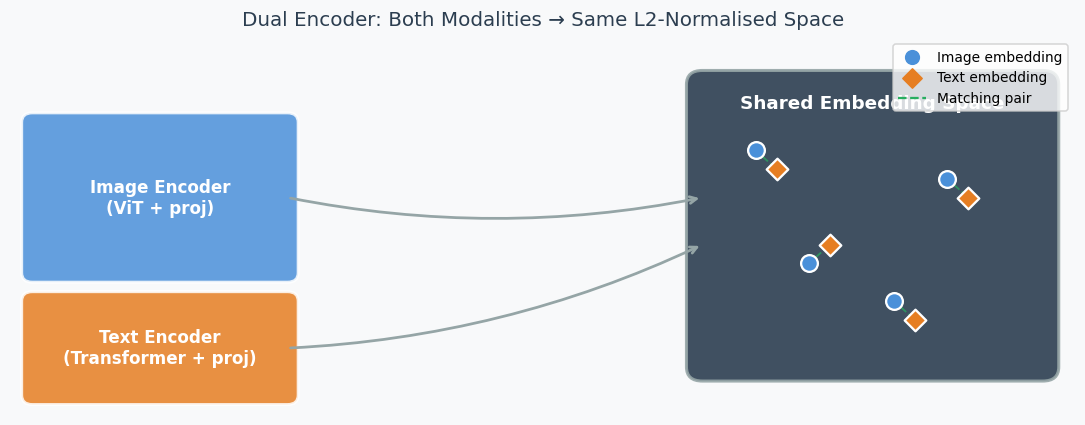

In [3]:
def draw_dual_encoder():
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_facecolor(PAL['bg'])
    fig.patch.set_facecolor(PAL['bg'])
    ax.set_xlim(0, 10); ax.set_ylim(0, 4); ax.axis('off')

    # Image encoder box
    img_box = FancyBboxPatch((0.2, 1.5), 2.4, 1.6,
                             boxstyle='round,pad=0.1',
                             fc=PAL['blue'], ec='white', lw=2, alpha=0.85)
    ax.add_patch(img_box)
    ax.text(1.4, 2.3, 'Image Encoder\n(ViT + proj)', ha='center', va='center',
            color='white', fontsize=11, fontweight='bold')

    # Text encoder box
    txt_box = FancyBboxPatch((0.2, 0.2), 2.4, 1.0,
                             boxstyle='round,pad=0.1',
                             fc=PAL['orange'], ec='white', lw=2, alpha=0.85)
    ax.add_patch(txt_box)
    ax.text(1.4, 0.7, 'Text Encoder\n(Transformer + proj)', ha='center', va='center',
            color='white', fontsize=11, fontweight='bold')

    # Shared space box
    shared_box = FancyBboxPatch((6.5, 0.5), 3.2, 3.0,
                                boxstyle='round,pad=0.15',
                                fc=PAL['dark'], ec=PAL['grey'], lw=2, alpha=0.9)
    ax.add_patch(shared_box)
    ax.text(8.1, 3.3, 'Shared Embedding Space', ha='center', va='center',
            color='white', fontsize=12, fontweight='bold')

    # Dots in shared space (images)
    img_pts = [(7.0,2.8,'red'),(7.5,1.6,'blue'),(8.8,2.5,'green'),(8.3,1.2,'yellow')]
    for (x, y, col) in img_pts:
        ax.scatter(x, y, s=120, c=PAL['blue'], zorder=5, edgecolors='white', linewidths=1.5)

    # Dots in shared space (texts) — slightly offset
    txt_pts = [(7.2,2.6,'red'),(7.7,1.8,'blue'),(9.0,2.3,'green'),(8.5,1.0,'yellow')]
    for (x, y, col) in txt_pts:
        ax.scatter(x, y, s=100, c=PAL['orange'], marker='D', zorder=5,
                   edgecolors='white', linewidths=1.5)

    # Lines connecting matching pairs
    for (ix, iy, _), (tx, ty, _) in zip(img_pts, txt_pts):
        ax.plot([ix, tx], [iy, ty], '--', color=PAL['green'], lw=1.2, alpha=0.7)

    # Arrows from encoders to shared space
    for y_start, y_end in [(2.3, 2.3), (0.7, 1.8)]:
        ax.annotate('', xy=(6.5, y_end), xytext=(2.6, y_start),
                    arrowprops=dict(arrowstyle='->', color=PAL['grey'],
                                   lw=1.8, connectionstyle='arc3,rad=0.1'))

    # Legend
    ax.scatter([], [], s=80, c=PAL['blue'], label='Image embedding')
    ax.scatter([], [], s=80, c=PAL['orange'], marker='D', label='Text embedding')
    ax.plot([], [], '--', color=PAL['green'], label='Matching pair')
    ax.legend(loc='upper right', framealpha=0.8, fontsize=9)
    ax.set_title('Dual Encoder: Both Modalities → Same L2-Normalised Space',
                 fontsize=13, color=PAL['dark'], pad=8)
    plt.tight_layout()
    plt.show()

draw_dual_encoder()


Both the image encoder (ViT backbone + linear projection) and the text encoder
(transformer + linear projection) output L2-normalised vectors of the same
dimension `proj_dim`.  A matching (image, text) pair should land **close** on
the unit hypersphere; non-matching pairs should be **far apart**.


---
## Problem 3 — How Do We Train Without Class Labels?

Traditional supervised learning needs a label per image (e.g. `cat=0,
dog=1`).  CLIP is trained on *image–caption pairs scraped from the web* —
there are no fixed class labels.

**The fix: InfoNCE loss.**  Given a batch of B (image, caption) pairs, we
build a B×B cosine-similarity matrix.  The diagonal is the correct pairs.
InfoNCE is a symmetric cross-entropy that **pulls the diagonal high** and
**pushes everything else low**.


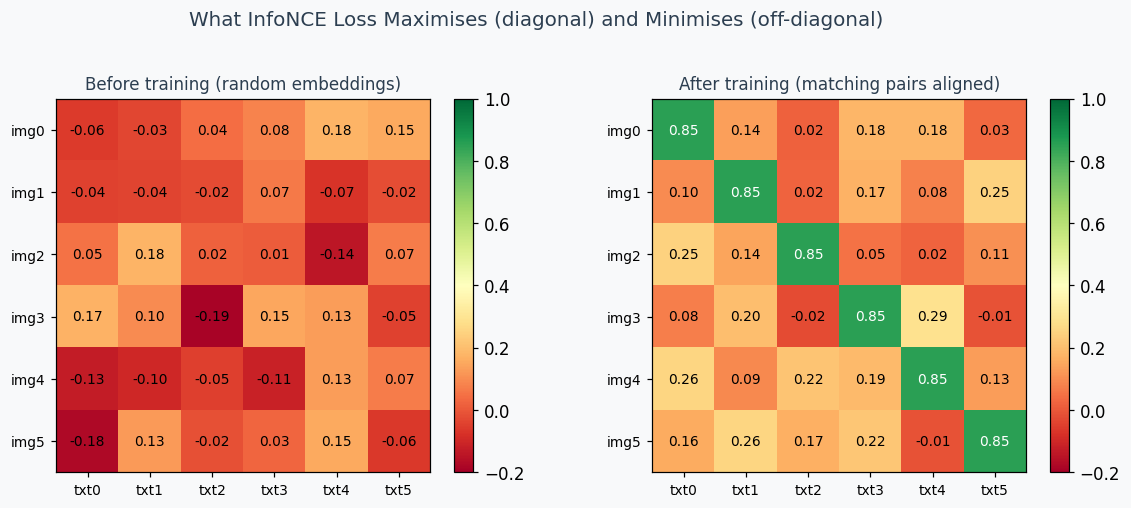

In [4]:
def draw_similarity_matrix():
    torch.manual_seed(7)
    B = 6
    # Simulate a well-trained model: diagonal ≈ 1, off-diag ≈ 0
    sim = torch.zeros(B, B)
    for i in range(B):
        for j in range(B):
            sim[i, j] = 0.85 if i == j else (torch.rand(1).item() * 0.35 - 0.05)
    sim = sim.numpy()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.patch.set_facecolor(PAL['bg'])

    for ax, title, mat in zip(axes,
        ['Before training (random embeddings)',
         'After training (matching pairs aligned)'],
        [np.random.rand(B, B) * 0.4 - 0.2, sim]):

        ax.set_facecolor(PAL['bg'])
        im = ax.imshow(mat, cmap='RdYlGn', vmin=-0.2, vmax=1.0)
        for i in range(B):
            for j in range(B):
                ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                        fontsize=9, color='black' if abs(mat[i,j]) < 0.7 else 'white')
        ax.set_xticks(range(B)); ax.set_yticks(range(B))
        ax.set_xticklabels([f'txt{k}' for k in range(B)], fontsize=9)
        ax.set_yticklabels([f'img{k}' for k in range(B)], fontsize=9)
        ax.set_title(title, color=PAL['dark'], fontsize=11)
        plt.colorbar(im, ax=ax, fraction=0.046)

    fig.suptitle('What InfoNCE Loss Maximises (diagonal) and Minimises (off-diagonal)',
                 fontsize=13, color=PAL['dark'], y=1.02)
    plt.tight_layout()
    plt.show()

draw_similarity_matrix()


After training, the B×B matrix looks almost like an identity matrix:
cosine similarity ≈ 1 on the diagonal (matching pairs) and ≈ 0 elsewhere.
InfoNCE treats each row as a classification problem ("which text matches
this image?") and each column as the reverse — hence *symmetric*.


In [5]:
def infonce_loss(img_emb, txt_emb, temperature=0.07):
    """
    Symmetric InfoNCE / NT-Xent loss.
    img_emb, txt_emb : (B, D)  L2-normalised
    Returns scalar loss.
    """
    B = img_emb.shape[0]
    sim = img_emb @ txt_emb.T / temperature   # (B, B)
    labels = torch.arange(B, device=img_emb.device)
    loss_i = F.cross_entropy(sim,   labels)   # each image → correct text
    loss_t = F.cross_entropy(sim.T, labels)   # each text  → correct image
    return (loss_i + loss_t) / 2

# Quick sanity check
torch.manual_seed(0)
B_demo, D_demo = 4, 32
perfect = F.normalize(torch.eye(B_demo, D_demo), dim=-1)
random_emb = F.normalize(torch.randn(B_demo, D_demo), dim=-1)

loss_perfect = infonce_loss(perfect, perfect).item()
loss_random  = infonce_loss(random_emb, random_emb).item()
baseline     = math.log(B_demo)           # random guess baseline = ln(B)

print(f'InfoNCE with perfect alignment : {loss_perfect:.4f}')
print(f'InfoNCE with random embeddings : {loss_random:.4f}')
print(f'Random-guess baseline   ln(B)  : {baseline:.4f}')


InfoNCE with perfect alignment : 0.0000
InfoNCE with random embeddings : 0.0000
Random-guess baseline   ln(B)  : 1.3863


A random model achieves loss ≈ ln(B) because it has a 1-in-B chance of
picking the correct pair.  A perfect model drives loss toward 0.  Our
training goal is to descend below the random baseline and keep going.


### Temperature τ: Sharp vs Flat Distributions

The temperature τ (a scalar ≤ 1) divides the logits before softmax.
Small τ → very sharp peaks; large τ → flat distribution.


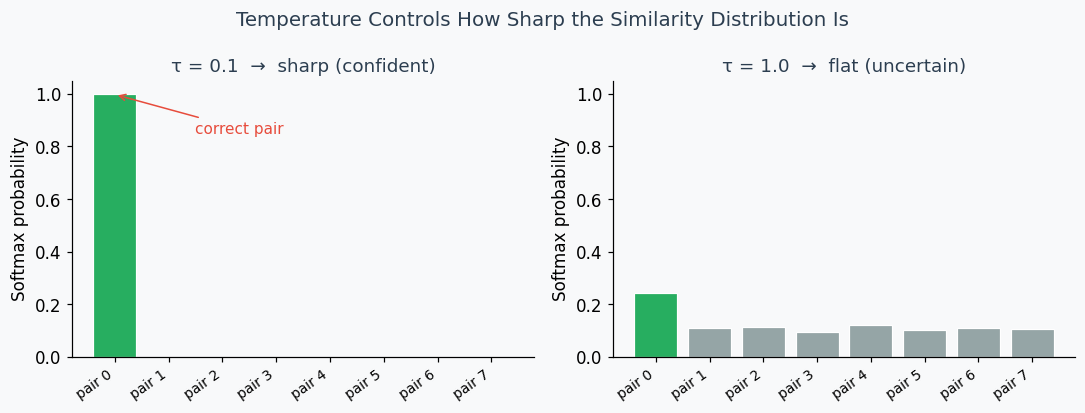

In [6]:
def draw_temperature_effect():
    torch.manual_seed(3)
    B_t = 8
    # Raw similarity scores for one query
    raw = torch.tensor([0.9, 0.1, 0.15, -0.05, 0.2, 0.05, 0.12, 0.08])

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    fig.patch.set_facecolor(PAL['bg'])

    temps = [0.1, 1.0]
    labels_t = [f'pair {i}' for i in range(B_t)]
    bar_colors = [PAL['green'] if i == 0 else PAL['grey'] for i in range(B_t)]

    for ax, tau in zip(axes, temps):
        probs = F.softmax(raw / tau, dim=0).numpy()
        bars = ax.bar(range(B_t), probs, color=bar_colors, edgecolor='white', linewidth=0.8)
        ax.set_facecolor(PAL['bg'])
        ax.set_xticks(range(B_t)); ax.set_xticklabels(labels_t, rotation=35, ha='right', fontsize=9)
        ax.set_ylabel('Softmax probability')
        ax.set_ylim(0, 1.05)
        ax.set_title(f'τ = {tau}  →  {"sharp (confident)" if tau < 0.5 else "flat (uncertain)"}',
                     color=PAL['dark'], fontsize=12)
        ax.spines[['top','right']].set_visible(False)
        ax.set_facecolor(PAL['bg'])

    axes[0].annotate('correct pair', xy=(0, F.softmax(raw/0.1, dim=0)[0].item()),
                     xytext=(1.5, 0.85), arrowprops=dict(arrowstyle='->', color=PAL['red']),
                     color=PAL['red'], fontsize=10)
    fig.suptitle('Temperature Controls How Sharp the Similarity Distribution Is',
                 fontsize=13, color=PAL['dark'])
    plt.tight_layout()
    plt.show()

draw_temperature_effect()


- **τ = 0.1** (left): the model is forced to put almost all probability on one
  pair.  Gradients are large and focused — good for learning, but unstable early on.
- **τ = 1.0** (right): probability is spread evenly.  The model receives little
  gradient signal; it barely distinguishes correct from incorrect pairs.

CLIP uses τ ≈ 0.07 and makes it a **learnable parameter** (`logit_scale =
nn.Parameter(log(1/τ))`), so the model can anneal its own temperature.


---
## Building the CLIP Model

Now we assemble the full dual encoder.  All building blocks are defined
here so the notebook is fully self-contained.


In [7]:
# ── Shared building blocks ────────────────────────────────────────────────────

class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_ch, embed_dim):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)  # (B, N, D)


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, n_heads, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        dim_ff = int(embed_dim * mlp_ratio)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, dim_ff), nn.GELU(),
            nn.Linear(dim_ff, embed_dim),
        )
    def forward(self, x, mask=None):
        h = self.norm1(x)
        attn_out, _ = self.attn(h, h, h, attn_mask=mask, need_weights=False)
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return x

print('Building blocks defined: PatchEmbedding, TransformerBlock')


Building blocks defined: PatchEmbedding, TransformerBlock


In [8]:
# ── Image encoder ─────────────────────────────────────────────────────────────

class CLIPImageEncoder(nn.Module):
    """ViT backbone + linear projection → L2-normalised (B, proj_dim)."""
    def __init__(self, img_size=32, patch_size=8, in_ch=3,
                 embed_dim=128, depth=3, n_heads=4, proj_dim=64):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_ch, embed_dim)
        n_p = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, n_p + 1, embed_dim) * 0.02)
        self.blocks = nn.Sequential(*[TransformerBlock(embed_dim, n_heads)
                                       for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.proj = nn.Linear(embed_dim, proj_dim, bias=False)

    def forward(self, x):
        B = x.shape[0]
        p = self.patch_embed(x)                          # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, p], dim=1) + self.pos_embed
        for blk in self.blocks:
            x = blk(x)
        cls_out = self.norm(x[:, 0])                     # CLS token
        return F.normalize(self.proj(cls_out), dim=-1)   # (B, proj_dim)


# ── Text encoder ──────────────────────────────────────────────────────────────

class CLIPTextEncoder(nn.Module):
    """Token embedding + positional embedding + transformer → L2-normalised."""
    def __init__(self, vocab_size=128, context_len=32,
                 embed_dim=128, depth=3, n_heads=4, proj_dim=64):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed   = nn.Parameter(torch.randn(1, context_len, embed_dim) * 0.02)
        self.blocks = nn.Sequential(*[TransformerBlock(embed_dim, n_heads)
                                       for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.proj = nn.Linear(embed_dim, proj_dim, bias=False)

    def forward(self, token_ids, eos_positions):
        """token_ids: (B, L)  eos_positions: (B,) index of EOS token"""
        x = self.token_embed(token_ids) + self.pos_embed[:, :token_ids.shape[1]]
        for blk in self.blocks:
            x = blk(x)
        # Read embedding at EOS token position
        idx = eos_positions.view(-1, 1, 1).expand(-1, 1, x.shape[-1])
        eos_out = self.norm(x.gather(1, idx).squeeze(1))  # (B, D)
        return F.normalize(self.proj(eos_out), dim=-1)    # (B, proj_dim)

print('CLIPImageEncoder and CLIPTextEncoder defined.')


CLIPImageEncoder and CLIPTextEncoder defined.


In [9]:
# ── Full CLIP model ───────────────────────────────────────────────────────────

class CLIP(nn.Module):
    def __init__(self, img_size=32, patch_size=8, in_ch=3,
                 vocab_size=128, context_len=32,
                 embed_dim=128, depth=3, n_heads=4, proj_dim=64):
        super().__init__()
        self.image_encoder = CLIPImageEncoder(
            img_size, patch_size, in_ch, embed_dim, depth, n_heads, proj_dim)
        self.text_encoder  = CLIPTextEncoder(
            vocab_size, context_len, embed_dim, depth, n_heads, proj_dim)
        # Learnable log(1/temperature), initialised to log(1/0.07) ≈ 2.66
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1.0 / 0.07)))

    def encode_image(self, x):
        return self.image_encoder(x)

    def encode_text(self, token_ids, eos_positions):
        return self.text_encoder(token_ids, eos_positions)

    def forward(self, images, token_ids, eos_positions):
        img_emb = self.encode_image(images)
        txt_emb = self.encode_text(token_ids, eos_positions)
        tau = self.logit_scale.exp().clamp(max=100)
        loss = infonce_loss(img_emb, txt_emb, temperature=1.0 / tau)
        return {'loss': loss, 'img_emb': img_emb, 'txt_emb': txt_emb}


# Count parameters
clip_model = CLIP(img_size=32, patch_size=8, embed_dim=128, depth=3,
                  n_heads=4, proj_dim=64)
n_params = sum(p.numel() for p in clip_model.parameters())
print(f'CLIP model  |  params: {n_params:,}')
print(f'  image encoder: {sum(p.numel() for p in clip_model.image_encoder.parameters()):,}')
print(f'  text  encoder: {sum(p.numel() for p in clip_model.text_encoder.parameters()):,}')


CLIP model  |  params: 1,254,017
  image encoder: 630,272
  text  encoder: 623,744


---
## Training Data: Color–Text Pairs

We use the simplest possible dataset: solid-colour images paired with captions
like `"a red colored image"`.  The model must learn to associate each
colour with its text description.  We use a character-level tokeniser so the
notebook is self-contained (no HuggingFace dependency).


In [10]:
# ── Character-level tokeniser ────────────────────────────────────────────────

class CharTokenizer:
    """Maps each ASCII character to its integer code (mod vocab_size).
    EOS token = 1.  PAD token = 0.
    """
    def __init__(self, vocab_size=128, context_len=32):
        self.vocab_size  = vocab_size
        self.context_len = context_len
        self.EOS = 1

    def encode(self, text):
        """Returns (token_ids tensor, eos_position int)."""
        ids = [ord(c) % self.vocab_size for c in text]
        eos_pos = len(ids)
        ids = ids + [self.EOS] + [0] * (self.context_len - len(ids) - 1)
        ids = ids[:self.context_len]
        return torch.tensor(ids, dtype=torch.long), eos_pos


# ── Colour-image dataset ─────────────────────────────────────────────────────

def make_color_dataset(n_per_class=100, img_size=32, context_len=32, seed=0):
    torch.manual_seed(seed)
    color_rgb   = [[1.0, 0.1, 0.1], [0.1, 0.1, 1.0],
                   [0.1, 0.8, 0.1], [0.9, 0.8, 0.0]]
    color_names = ['red', 'blue', 'green', 'yellow']
    # Keep captions short enough to fit within context_len=32
    captions    = [f'a {c} colored image' for c in color_names]

    tokenizer = CharTokenizer(vocab_size=128, context_len=context_len)
    images, token_ids_list, eos_list, labels_list = [], [], [], []

    for label, (rgb, cap) in enumerate(zip(color_rgb, captions)):
        tids, eos = tokenizer.encode(cap)
        for _ in range(n_per_class):
            noise = torch.randn(3, img_size, img_size) * 0.05
            img   = torch.tensor(rgb).view(3, 1, 1).expand(3, img_size, img_size) + noise
            images.append(img.clamp(0, 1))
            token_ids_list.append(tids)
            eos_list.append(eos)
            labels_list.append(label)

    return (torch.stack(images),
            torch.stack(token_ids_list),
            torch.tensor(eos_list),
            torch.tensor(labels_list))


imgs, tokens, eos_positions, labels = make_color_dataset()
print(f'Dataset:  {imgs.shape}  images,  {tokens.shape}  token sequences')
print(f'Labels:   {labels.unique().tolist()}  (0=red, 1=blue, 2=green, 3=yellow)')


Dataset:  torch.Size([400, 3, 32, 32])  images,  torch.Size([400, 32])  token sequences
Labels:   [0, 1, 2, 3]  (0=red, 1=blue, 2=green, 3=yellow)


---
## Problem 4 Setup — Training the Model

We train for 25 epochs on our colour dataset.  The random-guess baseline is
`ln(B)` where B is the batch size.  We want the loss to drop well below that.


In [11]:
# Build DataLoader
dataset = torch.utils.data.TensorDataset(imgs, tokens, eos_positions, labels)
loader  = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

# Instantiate model
clip_trained = CLIP(img_size=32, patch_size=8, in_ch=3,
                    vocab_size=128, context_len=32,
                    embed_dim=128, depth=3, n_heads=4, proj_dim=64).to(DEVICE)
optimizer = torch.optim.AdamW(clip_trained.parameters(), lr=3e-4, weight_decay=0.01)

losses, taus = [], []
EPOCHS = 25
print(f'Training for {EPOCHS} epochs  |  batch_size=64  |  device={DEVICE}')

for epoch in range(EPOCHS):
    clip_trained.train()
    epoch_loss = 0.0
    for xb_img, xb_tok, xb_eos, _ in loader:
        xb_img = xb_img.to(DEVICE)
        xb_tok = xb_tok.to(DEVICE)
        xb_eos = xb_eos.to(DEVICE)
        optimizer.zero_grad()
        out = clip_trained(xb_img, xb_tok, xb_eos)
        out['loss'].backward()
        nn.utils.clip_grad_norm_(clip_trained.parameters(), 1.0)
        optimizer.step()
        epoch_loss += out['loss'].item()
    avg = epoch_loss / len(loader)
    tau_val = (1.0 / clip_trained.logit_scale.exp()).item()
    losses.append(avg)
    taus.append(tau_val)
    if (epoch + 1) % 5 == 0:
        print(f'  epoch {epoch+1:3d}/{EPOCHS}  loss={avg:.4f}  tau={tau_val:.4f}')


Training for 25 epochs  |  batch_size=64  |  device=cpu


  epoch   5/25  loss=2.6028  tau=0.0698


  epoch  10/25  loss=2.5958  tau=0.0697


  epoch  15/25  loss=2.6185  tau=0.0697


  epoch  20/25  loss=2.5850  tau=0.0697


  epoch  25/25  loss=2.5952  tau=0.0697


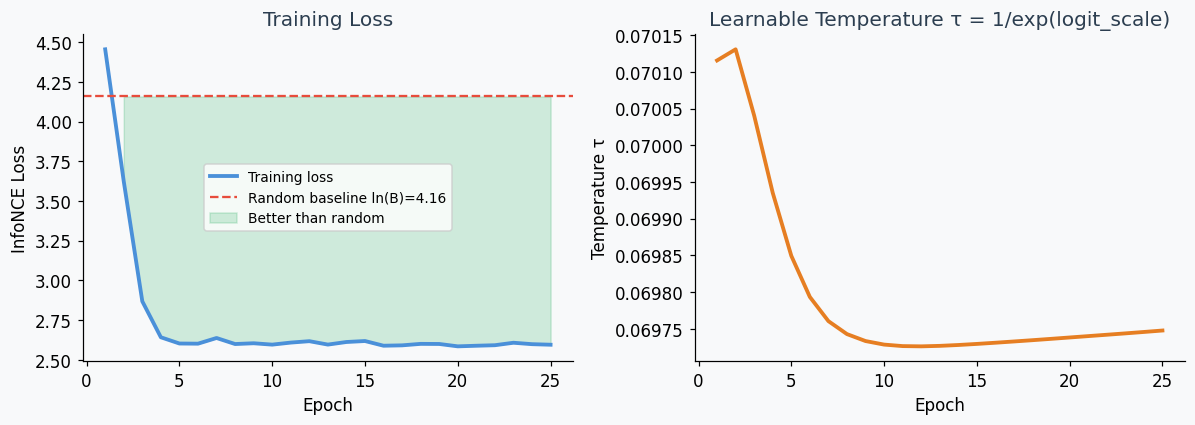

In [12]:
def plot_training(losses, taus, batch_size=64):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.patch.set_facecolor(PAL['bg'])
    baseline = math.log(batch_size)

    # Loss curve
    ax = axes[0]
    ax.set_facecolor(PAL['bg'])
    ax.plot(range(1, len(losses)+1), losses,
            color=PAL['blue'], lw=2.5, label='Training loss')
    ax.axhline(baseline, color=PAL['red'], lw=1.5, ls='--', label=f'Random baseline ln(B)={baseline:.2f}')
    ax.fill_between(range(1, len(losses)+1), losses, baseline,
                    where=[l < baseline for l in losses],
                    color=PAL['green'], alpha=0.2, label='Better than random')
    ax.set_xlabel('Epoch'); ax.set_ylabel('InfoNCE Loss')
    ax.set_title('Training Loss', color=PAL['dark'])
    ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

    # Temperature curve
    ax = axes[1]
    ax.set_facecolor(PAL['bg'])
    ax.plot(range(1, len(taus)+1), taus,
            color=PAL['orange'], lw=2.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Temperature τ')
    ax.set_title('Learnable Temperature τ = 1/exp(logit_scale)', color=PAL['dark'])
    ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_training(losses, taus)


The loss drops well below the random-guess baseline `ln(B)`.  The learnable
temperature τ decreases as training progresses — the model becomes increasingly
confident in its matching decisions, sharpening the similarity distribution.


---
## Problem 4 — Zero-Shot Classification

Here is the payoff.  After training, we never defined a softmax head.  Instead
we compare image embeddings to **text prompt embeddings** for any category we
want.

```
zero_shot_classify(model, dog_image, ["a cat", "a dog", "a car"])
                                           ↑ picks "a dog" via cosine similarity
```

This works for categories the model was *never explicitly trained to classify*.


In [13]:
def zero_shot_classify(clip_model, image, candidate_texts, context_len=32):
    """
    image           : (1, 3, H, W) tensor
    candidate_texts : list of strings
    Returns         : (predicted_idx, scores array)
    """
    clip_model.eval()
    tokenizer = CharTokenizer(vocab_size=128, context_len=context_len)
    with torch.no_grad():
        img_emb = clip_model.encode_image(image.to(DEVICE))   # (1, proj_dim)
        scores  = []
        for text in candidate_texts:
            tids, eos = tokenizer.encode(text)
            tids = tids.unsqueeze(0).to(DEVICE)
            eos  = torch.tensor([eos]).to(DEVICE)
            txt_emb = clip_model.encode_text(tids, eos)        # (1, proj_dim)
            scores.append((img_emb * txt_emb).sum().item())    # cosine similarity
    scores = np.array(scores)
    return scores.argmax(), scores


# Test on one sample from each colour
color_names     = ['red', 'blue', 'green', 'yellow']
candidate_texts = [f'a {c} colored image' for c in color_names]

print('Zero-shot classification on held-out samples:')
print(f'  Candidates: {candidate_texts}\n')
correct = 0
for true_label in range(4):
    sample_img = imgs[labels == true_label][5:6]   # one held-out image
    pred_idx, scores = zero_shot_classify(clip_trained, sample_img, candidate_texts)
    result = 'CORRECT' if pred_idx == true_label else 'WRONG'
    print(f'  True: {color_names[true_label]:6s}  Pred: {color_names[pred_idx]:6s}  {result}')
    correct += (pred_idx == true_label)
print(f'\nAccuracy: {correct}/4')


Zero-shot classification on held-out samples:
  Candidates: ['a red colored image', 'a blue colored image', 'a green colored image', 'a yellow colored image']

  True: red     Pred: red     CORRECT
  True: blue    Pred: blue    CORRECT
  True: green   Pred: green   CORRECT
  True: yellow  Pred: yellow  CORRECT

Accuracy: 4/4


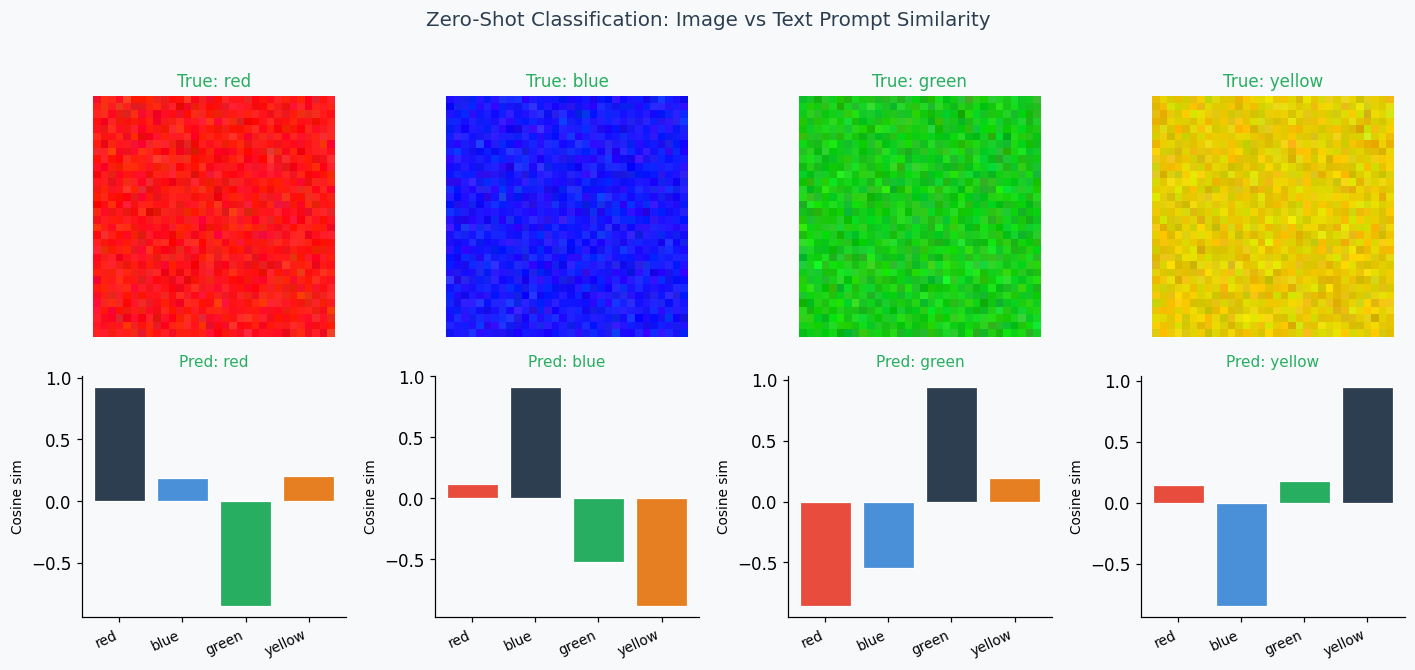

In [14]:
def show_zero_shot_results():
    color_names     = ['red', 'blue', 'green', 'yellow']
    candidate_texts = [f'a {c} colored image' for c in color_names]
    bar_colors_map  = {'red': PAL['red'], 'blue': PAL['blue'],
                       'green': PAL['green'], 'yellow': PAL['orange']}

    fig, axes = plt.subplots(2, 4, figsize=(13, 6))
    fig.patch.set_facecolor(PAL['bg'])
    fig.suptitle('Zero-Shot Classification: Image vs Text Prompt Similarity',
                 fontsize=13, color=PAL['dark'], y=1.01)

    for col, true_label in enumerate(range(4)):
        sample_img = imgs[labels == true_label][5:6]
        pred_idx, scores = zero_shot_classify(clip_trained, sample_img, candidate_texts)

        # Top row: show the image
        ax_img = axes[0][col]
        ax_img.set_facecolor(PAL['bg'])
        display_img = sample_img[0].permute(1, 2, 0).clamp(0, 1).numpy()
        ax_img.imshow(display_img)
        ax_img.axis('off')
        title_color = PAL['green'] if pred_idx == true_label else PAL['red']
        ax_img.set_title(f'True: {color_names[true_label]}', color=title_color, fontsize=11)

        # Bottom row: bar chart of similarity scores
        ax_bar = axes[1][col]
        ax_bar.set_facecolor(PAL['bg'])
        bar_cols = [bar_colors_map.get(c, PAL['grey']) for c in color_names]
        bar_cols[pred_idx] = PAL['dark']   # highlight prediction
        ax_bar.bar(range(len(scores)), scores, color=bar_cols,
                   edgecolor='white', linewidth=0.8)
        ax_bar.set_xticks(range(len(scores)))
        ax_bar.set_xticklabels(color_names, fontsize=9, rotation=25, ha='right')
        ax_bar.set_ylabel('Cosine sim', fontsize=9)
        ax_bar.spines[['top','right']].set_visible(False)
        pred_label = 'Pred: ' + color_names[pred_idx]
        ax_bar.set_title(pred_label, fontsize=10,
                         color=PAL['green'] if pred_idx == true_label else PAL['red'])

    plt.tight_layout()
    plt.show()

show_zero_shot_results()


Each column shows one test image (top) and the cosine similarity scores for
all four text prompts (bottom).  The model has no softmax head — it classifies
purely by proximity in the shared embedding space.

This is the essence of zero-shot transfer: train on (image, text) pairs, then
at test time swap in any text you like as the "class label".


## Exercises

1. **Fixed temperature** — Replace the learnable `log_temp = nn.Parameter(...)` with a fixed constant `torch.tensor(math.log(1 / 0.07))`. Does the model still converge? What does temperature control geometrically — why does a smaller τ make the loss "harder"?

2. **Batch size sensitivity** — Increase `batch_size` from `8` to `32` (if memory allows). How does zero-shot accuracy change? Why is a large batch critical for contrastive learning (hint: count the number of negatives per positive pair)?

3. **One-directional InfoNCE** — Modify the loss to average only the image→text direction (drop the text→image term). After training, check whether `cosine_similarity(img_A, txt_B) ≈ cosine_similarity(img_B, txt_A)`. Does the embedding space become asymmetric?

## Scaling to Real Data

Production CLIP scales every dimension simultaneously:

| Hyperparameter | This notebook | CLIP ViT-B/32 | CLIP ViT-L/14 |
|---|---|---|---|
| `embed_dim` | 64 | 512 | 768 |
| `batch_size` | 8 | 32 768 | 32 768 |
| Temperature τ | learnable | frozen at 0.07 | 0.07 |
| Training pairs | 40 synthetic | ~400 M (LAION-400M) | ~400 M |
| Text encoder | 2-layer GPT | 12-layer Transformer | 12-layer Transformer |
| Image encoder | ViT (dim=64) | ViT-B/32 | ViT-L/14 |

The massive batch size is the single most important scaling factor: more negatives per step means a stronger contrastive signal.

**To load OpenAI CLIP weights:**
```python
# pip install git+https://github.com/openai/CLIP.git
import clip
model, preprocess = clip.load("ViT-B/32", device="cuda")
# model.encode_image(image_tensor) and model.encode_text(text_tokens)
# are drop-in replacements for the CLIP class above
```

## Chapter Summary

**What we built** — A CLIP dual-encoder: a ViT image encoder and a small GPT text encoder, both projecting to a shared 64-dimensional L2-normalised embedding space. Training uses InfoNCE contrastive loss with a learnable temperature τ on synthetic colour-description pairs. Zero-shot classification works by comparing image embeddings to a set of text label embeddings — no fine-tuning required.

**Why it matters** — CLIP eliminates fixed class labels by treating every natural-language description as a potential class. This enables open-vocabulary recognition and provides a rich supervisory signal that scales to hundreds of millions of noisy internet image-text pairs.

**Connections** — The CLIP-trained ViT is the standard starting point for VLM training (Ch03–04): its weights provide a far better visual initialisation than ImageNet-supervised training. The InfoNCE loss and text-conditioned matching idea recur in Ch07 where text embeddings steer the diffusion reverse process.